<a href="https://colab.research.google.com/github/franclouis-42/ap155lab_ay26271/blob/main/ap155_0prelims_surname.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AP 155 Lab Assignment
---
## Exercise 0: Preliminaries

_Instruction_:
* Complete your student information and familiarize yourself with the lab output notebook.
* Set up the JupyterLab–GitHub workflow, create your own repository, and push your submission.
* Use idiomatic Python, NumPy, and Matplotlib to implement the logistic map and reproduce the given bifurcation diagram using efficient, vectorized operations.
* Briefly justify your numerical approach, parameter choices, and treatment of transient behavior. Ensure the resulting figure clearly shows the expected bifurcation structure.

---

### Student Information
_Full Name (Last Name, First Name)_: Ranches, Franc Louis

_Student No._: 2024-09153

_Section_: THR-TX-3

### Grading (this may still be modified but more or less it'll be like this)
<img src='https://github.com/franclouis-42/ap155lab_ay26271/blob/main/figures/rubric.png?raw=1' width='75%' align='center'>

---
## Section 1: Report

We will check this section. In the report, we will require you to generate a specific figure related to the problem at hand. You should complete the elements in a figure (axes, units, labels, legends, etc.). Discuss what the figure represents.

We will also ask you to discuss the main result using guide questions (see Section 2 for what data you need to present here in Section 1).

### Bifurcation diagram

<img src="https://github.com/franclouis-42/ap155lab_ay26271/blob/main/figures/cat.jpg?raw=1" width="45%" align="center">   <img src="https://github.com/franclouis-42/ap155lab_ay26271/blob/main/figures/cat.jpg?raw=1" width="45%" align="center">

EDIT ME. Insert caption here. The syntax in markdown for putting a figure is `<img src="path/to/figure.png" width="75%">`. Describe the figure briefly and concisely, and make sure the figure has complete elements.

EDIT ME. Insert your discussion here. Do not exceed 150 words for this paragraph. Make sure to emphasize the physics behind the problem.


### Others
- This subsection of the report discussion is ungraded
- It is encouraged that you include here your main takeaways and what problems you encountered

---
## Section 2: Code

We will check this section. Write your code below and document them properly (i.e. discuss why you use that particular function, library, flow control, etc.)
You should be able to...
- write clear, efficient, and idiomatic Python code for numerical physics applications
- select appropriate computational technique for a given physics problem and justify your choice

### Problems and Codes

**Model**
- The logistic map is a polynomial recurrence relation that models how populations change over discrete generations
  $$ x_{n+1} = r x_n (1-x_n) \tag{1} $$
  where $x_n$ is the population at year $n$ $x\in[0,1]$, $x_{n+1}$ is the population in the following year, and $r$ is the growth rate $r \in [1,4]$. A bifurcation diagram is a plot of the fixed points $x^*$ on the $y$-axis as a function of the growth rate $r$ on the $x$-axis. A fixed point is a value of $x$ that remains unchanged under the recursion relation, meaning that once the system reaches $x^*$, subsequent iterations remain at $x^*$. An interesting visualization is obtained: ![Figure](https://github.com/franclouis-42/ap155lab_ay26271/blob/main/figures/ap155_0_bifurcationdiagram.png?raw=1)

**Hint algorithm**
1. Generate $n=1000$ evenly spaced values of the growth rate $r$ over the interval $[1,4]$.
2. Initialize the population $x_0$ for each $r$-value. Use initial values in the interval $[0,1]$.
3. For each $r$, iterate the logistic map for $1000$ generations, see Eq. (1).
4. Discard the first $n=800$ iterations to remove transient behavior. Retain the final $n=200$ values, which represent the system's long-term behavior.
5. For each $r$, plot the retained $x_n$ values against $r$. A single $r$-value may therefore correspond to multiple $x_n$ values in periodic or chaotic regimes.
6. Label the axes appropriately and format the figure so that the period-doubling structure and chaotic regions are clearly visible.

- You may explore with loops first
- However, it is better to use vectorized NumPy operations where appropriate

#### Code

In [2]:
# You may use as many code blocks as you can

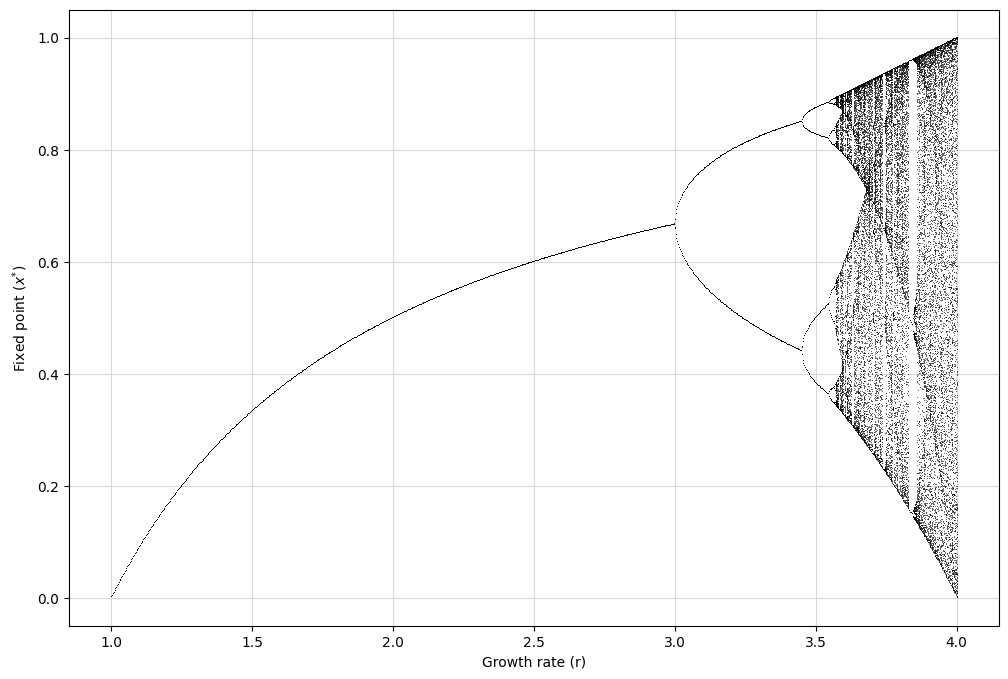

In [3]:
import numpy as np
import matplotlib.pyplot as pyplot

#generating values for r
r = np.linspace(1.0, 4.0, 1000)
#generating values for x_0
x_0 = np.random.uniform(0.0, 1.0, 1000)

#main list for r and x values
r_all = []
x_all = []

#generating x_n using r and x_0, where we use the previous value of x_0 to get the next one
for r_val, x_val in zip(r, x_0): #taking x value per r value
    x_current = x_val #sets the current x value to be the current x value
    x_n = [] #refreshes each loop

    for i in range(1000):
        #the recurrence formula, using x_current to generate the next
        x_current = r_val*x_current*(1-x_current)
        x_n.append(x_current)

    #inserting the current x and r values to the main list
    r_all.extend([r_val] * 200)
    x_all.extend(x_n[-200:])

#for plotting
pyplot.figure(figsize=(12, 8))
ax = pyplot.gca()
ax.set_facecolor('white')
ax.grid(True, color='0.85', linewidth=0.8)
ax.set_axisbelow(True)
pyplot.xlabel("Growth rate (r)")
pyplot.ylabel(r"Fixed point ($x^{*}$)")
pyplot.plot(r_all, x_all, ',', color = "black", alpha=0.6)
pyplot.savefig("bifurcation_diagram2.png")
pyplot.show()

To match the given diagram froom the example change the interval value of r from the interval [1,4] to [2.5,4]

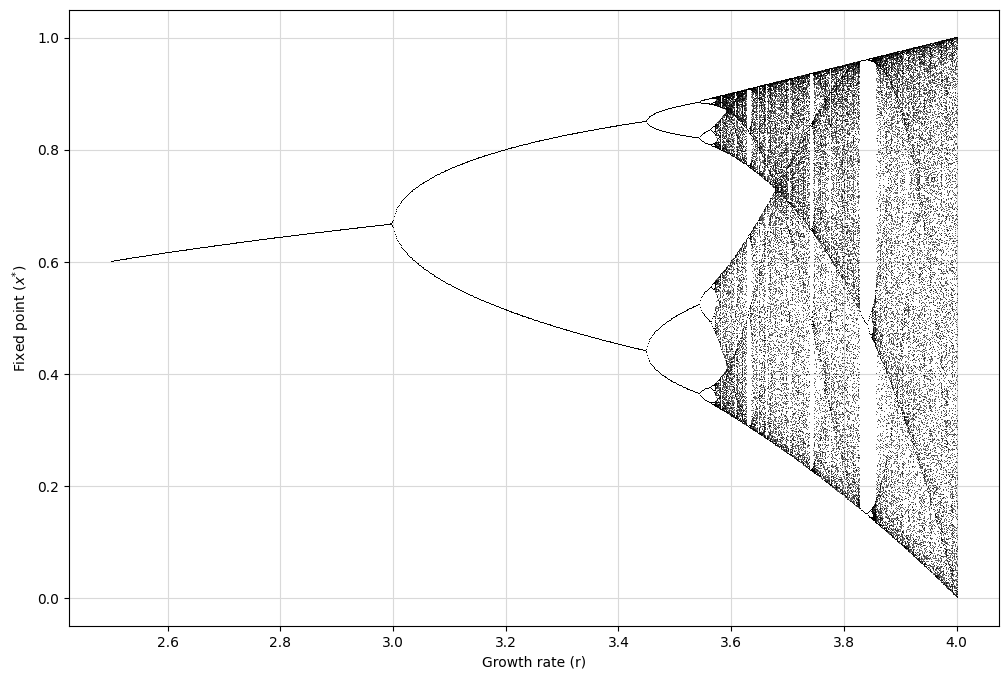

In [4]:
import numpy as np
import matplotlib.pyplot as pyplot

#generating values for r
r = np.linspace(2.5, 4.0, 1000)
#generating values for x_0
x_0 = np.random.uniform(0.0, 1.0, 1000)

#main list for r and x values
r_all = []
x_all = []

#generating x_n using r and x_0, where we use the previous value of x_0 to get the next one
for r_val, x_val in zip(r, x_0): #taking x value per r value
    x_current = x_val #sets the current x value to be the current x value
    x_n = [] #refreshes each loop

    for i in range(1000):
        #the recurrence formula, using x_current to generate the next
        x_current = r_val*x_current*(1-x_current)
        x_n.append(x_current)

    #inserting the current x and r values to the main list
    r_all.extend([r_val] * 200)
    x_all.extend(x_n[-200:])

#for plotting
pyplot.figure(figsize=(12, 8))
ax = pyplot.gca()
ax.set_facecolor('white')
ax.grid(True, color='0.85', linewidth=0.8)
ax.set_axisbelow(True)
pyplot.xlabel("Growth rate (r)")
pyplot.ylabel(r"Fixed point ($x^{*}$)")
pyplot.plot(r_all, x_all, ',', color = "black", alpha=0.6)
pyplot.show()

You may include documentation in between your code blocks to describe the critical parts of your code. We should specifically see why you built a particular method/flow control/function/library

Include AI disclosure statement if applicable. Give credit where it's due.

AI disclosure: I used Claude (Sonnet 5) to help debug plot formatting (axis range, labels, gridlines) and to polish the loop logic of the code.

---
## Section 3: Supplementary information

We will NOT check this section. In this section, we include the background concepts that are fundamental to the exercises given on that particular day. We may include pseudocodes, tips, or pipelines here.

#### Creation of server account (playpen.liknayan.com)

1. Access `https://playpen.liknayan.com/`
2. Click **Sign up** to create a new user
3. Write and remember your **Username** and **Password** (write this in paper and submit to lab instructor)
4. Admin admits student of application

#### Virtual environment

##### python3 venv
- `venv` is Python's built-in module for creating isolated virtual environments.
- It provides each project with its own self-contained directory for Python packages, keeping its dependencies completely separated from your computer's global Python installation and other projects.

(macOS/Linux)
1. Create the Virtual Environment: `python3 -m venv .venv`
2. Activate virtual environment: `source .venv/bin/activate`
3. Deactivate virtual environment: `deactivate`

- **BEST PRACTICE:** when working on a project especially when installing dependencies, always do so within the virtual environment
- **NOTE:** DO NOT DO GLOBAL INSTALLATIONS

#### Setting Up SSH and Git

Git is a version control system that allows you to keep track of changes to your files. We will use Git to save and version your code, notebooks, and figures on the server, and synchronize them with your own private GitHub repository.

#### Navigating in terminal (bash)

- To enter a folder:
    - `cd <folder-name>` (Example input: `cd ap155`)
- To move up one directory:
    - `cd ..`
- To return to your home directory:
    - `cd ~`
- To see your current location on the server, enter:
    - `pwd` (Example output: `/home/jovyan/work/ap155`)
- You can use the **Tab key** to autocomplete file and folder names in the terminal.
- To see the files and folders in your current directory:
    - `ls` (list)
- For a more detailed listing, you can use:
    - `ls -la` (la means long + all)

#### Create GitHub account + private repo

1. Go to GitHub and create an account (can be upmail or gmail).
2. Make a private repository (empty)
3. Make `jrgrefal` a collaborator in GitHub

#### Check that Git is installed via terminal

1. In the terminal, enter: `git --version`
2. You should see something similar to: `git version 2.34.1`
3. You can also check where Git is installed: `which git` (which will show `/usr/bin/git`)
4. If you see a Git version and a path to Git, Git is available on the server.

#### Check if current directory is already a Git repo

1. Navigate to your assigned project directory, then run:
    - `git status`
3. If the directory is already a Git repository, you should see something similar to:
    - `On branch main ...`
    - This means Git is already tracking your project.
5. If you see:
    - `fatal: not a git repository`
    - This means we need to initialize the repo.

#### Check Whether an SSH Key Already Exists

SSH keys allow the server to securely authenticate with GitHub without requiring you to enter your GitHub password every time.

1. Check whether an SSH directory already exists: `ls -la ~/.ssh`
2. You may see files such as: `id_ed25519,  id_ed25519.pub` (The files come in pairs: id_ed25519 is the private key, id_ed25519 is the public key)
3. The private key must remain private.
4. Never:
   - send your private key to anyone;
   - upload it to GitHub;
   - put it in your project repository;
   - paste it into a group chat;
   - include it in a report or screenshot.
5. The .pub file is the public key and may be added to your GitHub account when instructed.
6. If an SSH key already exists, do not overwrite it without first asking the instructor/server administrator.

#### SSH Key pairing

1. Generate key:
    - `ssh-keygen -t ed25519 -C "your-github-email@up.edu.ph"`
    - Replace the email with the email associated with your GitHub account.
2. When asked where to save the key, press Enter to use the default location:
    - `/home/jovyan/.ssh/id_ed25519`
3. You will also be asked for a passphrase.
    - Enter your password, remember this
    - Letters do not show when you type a password or passphrase in a bash terminal for security
4. After successful creation, you should input `ls` and see...
    - `~/.ssh/id_ed25519`
    - `~/.ssh/id_ed25519.pub`
5. Display your public key:
    - `cat ~/.ssh/id_ed25519.pub`
    - You should see one long line beginning with: `ssh-ed25519 ...`
    - **IMPORTANT** Only copy the contents of `id_ed25519.pub`. Never copy `id_ed25519`.
6. Copy the entire line.
7. On GitHub:
    1. Open Settings
    2. Select SSH and GPG keys
    3. Click New SSH key
    4. Give the key a title (example: `"ap155-server"`) and **paste your public key into the key field**
8. Return to the server terminal and run:
    - `ssh -T git@github.com`
    - The first time you connect, you may be asked whether you trust GitHub's host key.
    - If everything is configured correctly, you may see something similar to...
    - `Hi <your-username>! You've successfully authenticated, but GitHub does not provide shell access.`
9. Go to your private repo in GitHub --> click Code --> copy SSH key
    - it should look something like `git@github.com:username/your-repo-name.git`
10. In terminal, set your remote repository URL to SSH:
    - `git remote add origin git@github.com:username/your-repo-name.git`

#### Creating a private repo in GitHub

1. Create a new, empty repository on GitHub
    - Go to github.com/new and give your repository a name
    - Leave Add a README file, Add .gitignore, and Choose a license **UNCHECKED**.
2. In terminal, go inside your working directory (the folder you want to **upload** from server to GitHub as a repository)
3. Initialize Git and add files/commit
   - `git init`
   - `git config user.name "Your Name"`
    - `git config user.email "your_email@example.com"`
    - `git add .` # the dot means add everything in current directory
    - `git commit -m "Initial commit"` # change Initial commit to whatever message or comment u did
5. Rename your default branch to main:
    - `git branch -M main` # make this directory your main branch
6. Connect your local folder to the GitHub repository
    - Go to your GitHub empty repo and copy the SSH key:
    - In terminal: `git remote add origin git@github.com:your-username/your-repo-name.git`
7. Push your code to GitHub:
    - `git push -u origin main` # push to main; -u makes git remember where next uploads go
9. You may need to config your name and username here, follow instructions on terminal.

12. Afterwards, further modifications in this repo will only require the following in the future:
    1. `git add .`
    2. `git commit -m "Message"`
    3. `git push`

#### Forking and pulling in GitHub

1. Fork the original repository (in GitHub)
    - Navigate to the instructor's original repository ([https://github.com/jrgrefal/ap155lab_ay26271](https://github.com/jrgrefal/ap155lab_ay26271))
    - click Fork at the top right, and save a copy to your own GitHub account.
2. Clone your fork to your local machine (in terminal)
    - `git clone git@github.com:your-username/ap155lab_ay26271.git`
3. Enter the cloned repo:
    - `cd ap155lab_ay26271`
4. Add the original repository as 'upstream'
    - `git remote add upstream https://github.com/jrgrefal/ap155lab_ay26271.git`
    - This links the original repo so you can fetch updates from the instructor later
5. Create a new branch dedicated to your submission:
    - `git switch -c exercise0-submission`
6. Complete your work
    - Open the files in your editor, complete the exercises, and save your changes.
7. Review, stage, and commit your work:
    - `git status`
    - `git add .`
    - `git commit -m "Complete exercises for today's lab"`
8. Push your branch to your fork
    - `git push -u origin exercise0-submission`
    - This uploads your local assignment-submission branch to your GitHub fork (origin)
9. Open a Pull Request (in GitHub)
    - Go to your fork's page on GitHub
    - Click Compare & pull request (or New Pull Request).
    - Click Create Pull Request and submit.
  
**Notes**
1. Sync your main branch with the Original Repo
    - `git switch main`             # 1. Switch to your main branch
    - `git pull upstream main`      # 2. Fetch AND merge upstream changes in 1 step
    - `git push origin main`        # 3. Update your GitHub fork's main branch
2. Bring those updates into your active work branch
    - `git switch assignment-submission`
    - `git merge main`
3. Daily edit, commit, and push cycle
    - `git add .`
    - `git commit -m "Describe your changes"`
    - `git push`

#### Submission pipeline

The basic workflow will eventually be:
1. We will provide exercise for the day via ipynb file hosted in a GitHub repo
2. You may either...
    1. Fork the repo and submit (work in the server)
    2. Create a colab duplicate by changing clicking the notebook and changing the URL  from `github.com` to `githubtocolab.com` (you may need to authenticate Colab-GitHub)
3. Submit your final ipynb file (containing your answers/responses) to the google drive link:
    - LINK: [https://drive.google.com/drive/folders/1BBGKurw44FBfBDNeaDBAxHElG1YAPhfY?usp=sharing](https://drive.google.com/drive/folders/1BBGKurw44FBfBDNeaDBAxHElG1YAPhfY?usp=sharing)

#### Python basics

1. Open a terminal and check if you have Python installed, then make a notebook inside a
directory
2. Learn the following:
    - differentiate basic data types (int, floats, strings)
    - `print()`
    - arithmetic, floor division
    - `==` vs `=`
    - `x+=1`
    - if-elif-else
    - for loops
    - while loops
    - list, tuple, string, dictionary
    - functions (return, positional, keyword arguments)
    - list comprehension (slice, reassignment, append, flow control)
    - string formatting
4. Learn how to import libraries
    - numpy
    - matplotlib